# Experiment C — One-Class Authenticator (CNN Embedding + One-Class SVM)
**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting  
**Authors:** Amitha · Tharangi Madushani  
**Supervisor:** Prof. Qinghua Wang

---

## Concept

The Experiment A 1D CNN is frozen and used as a **feature extractor**.
Its penultimate Dense-64 layer produces a 64-dimensional embedding that encodes
device-specific hardware impairments. A One-Class SVM trained on DEV01 embeddings
only defines the authentication boundary.

```
IQ window (128×2)
      ↓
Frozen 1D CNN  ← weights from Experiment A, unchanged
      ↓
64-dim embedding  ← hardware fingerprint space
      ↓
One-Class SVM  ← trained on DEV01 only
      ↓
ACCEPT (DEV01) / REJECT (impostor)
```

**Key properties:**
- CNN architecture: identical to Experiment A (43,874 parameters)
- No impostor data used in training — true one-class scenario
- All 4 modulations + S1+S2 + noise augmentation
- Threshold: FAR ≤ 5% on validation set (SR-2)

**Evaluation:** TAR and FAR per modulation per SNR — consistent values across
modulations proves hardware fingerprint, not modulation-specific pattern.

## Section 1 — Mount Drive + Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import gc

BASE         = '/content/drive/MyDrive/My Thesis (main)'
PREPROCESSED = os.path.join(BASE, 'Preprocessed')
EXP_A_MODEL  = os.path.join(BASE, 'Models', 'ExperimentA',
                             'best_model_augmented.keras')
MODEL_DIR    = os.path.join(BASE, 'Models', 'ExperimentC_v2')
os.makedirs(MODEL_DIR, exist_ok=True)

MODULATIONS  = ['BPSK', 'QPSK', 'GFSK', 'OOK']
SESSIONS     = ['S1', 'S2']
AUG_TAGS     = ['clean', 'SNR10', 'SNR0']
EVAL_SNRS    = [None, 20, 10, 0]
TARGET_FAR   = 0.05
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

experiment_C_results = {}

print(f'BASE contents : {os.listdir(BASE)}')
print(f'Exp A model   : {os.path.exists(EXP_A_MODEL)}')
print(f'Output dir    : {MODEL_DIR}')
print(f'TF            : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU           : {gpus[0].name if gpus else "CPU only"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE contents : ['Literature', 'My LR Drafts', 'midway-seminar prep.pptx', 'Simulations', 'Models', 'Recordings', 'GNU Radio', 'Notebooks', 'Preprocessed']
Exp A model   : True
Output dir    : /content/drive/MyDrive/My Thesis (main)/Models/ExperimentC_v2
TF            : 2.20.0
GPU           : /physical_device:GPU:0


## Section 2 — Load Experiment A Model + Build Embedding Extractor

In [2]:
# Load the full trained model from Experiment A
full_model = keras.models.load_model(EXP_A_MODEL)
print('Experiment A model loaded.')
full_model.summary()

# Build embedding extractor — output from Dense-64 layer (before Dropout+Softmax)
# Find the Dense-64 layer by scanning layer names
for i, layer in enumerate(full_model.layers):
    print(f'  [{i:2d}] {layer.name:40s} {str(layer.output.shape)}')


Experiment A model loaded.


Model: "RFF_CNN_ExperimentA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ iq_input (InputLayer)           │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 122, 32)        │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling1D)        │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 57, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling1D)        │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 26, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (AveragePooling1D)        │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg                      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,624 (514.16 KB)

 Trainable params: 43,874 (171.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 87,750 (342.78 KB)

  [ 0] iq_input                                 (None, 128, 2)
  [ 1] conv1                                    (None, 122, 32)
  [ 2] pool1                                    (None, 61, 32)
  [ 3] conv2                                    (None, 57, 64)
  [ 4] pool2                                    (None, 28, 64)
  [ 5] conv3                                    (None, 26, 128)
  [ 6] pool3                                    (None, 13, 128)
  [ 7] global_avg                               (None, 128)
  [ 8] dense1                                   (None, 64)
  [ 9] dropout                                  (None, 64)
  [10] output                                   (None, 2)


In [3]:
# The Dense-64 layer is the embedding layer
# It is the last Dense layer before Dropout and Softmax
dense64_layer = None
for layer in full_model.layers:
    if isinstance(layer, layers.Dense) and layer.units == 64:
        dense64_layer = layer
        print(f'Found embedding layer: {layer.name}')

assert dense64_layer is not None, 'Dense-64 layer not found — check model architecture'

# Build extractor model: same input, output = Dense-64 activations
embedding_model = keras.Model(
    inputs=full_model.input,
    outputs=dense64_layer.output,
    name='embedding_extractor'
)
embedding_model.trainable = False  # frozen

print(f'\nEmbedding extractor built.')
print(f'Input  : {embedding_model.input.shape}')
print(f'Output : {embedding_model.output.shape}')

# Quick sanity check
test_input = np.random.randn(4, 128, 2).astype(np.float32)
test_emb   = embedding_model.predict(test_input, verbose=0)
print(f'Test embedding shape: {test_emb.shape}  (expected (4, 64))')

Found embedding layer: dense1

Embedding extractor built.
Input  : (None, 128, 2)
Output : (None, 64)
Test embedding shape: (4, 64)  (expected (4, 64))


## Section 3 — Data Loading Helpers

In [4]:
def load_npy(session, modulation, snr_tag, retries=3):
    folder = os.path.join(PREPROCESSED, session)
    x_path = os.path.join(folder, f'{modulation}_{snr_tag}_X.npy')
    y_path = os.path.join(folder, f'{modulation}_{snr_tag}_y.npy')
    for attempt in range(retries):
        try:
            X = np.load(x_path)
            y = np.load(y_path)
            return X, y
        except OSError as e:
            if attempt < retries - 1:
                print(f'  Drive error on {modulation}/{session}/{snr_tag} '
                      f'— retrying ({attempt+1}/{retries})...')
                time.sleep(5)
            else:
                raise e

def snr_tag(snr_level):
    return 'clean' if snr_level is None else f'SNR{snr_level}'

def get_embeddings(X_iq, batch_size=1024):
    return embedding_model.predict(X_iq, batch_size=batch_size, verbose=0)

def load_dev01_training_embeddings(verbose=True):
    parts = []
    for mod in MODULATIONS:
        for sess in SESSIONS:
            for tag in AUG_TAGS:
                X, y = load_npy(sess, mod, tag)
                X_dev01 = X[y == 0]
                emb = get_embeddings(X_dev01)
                parts.append(emb)
                if verbose:
                    print(f'  {mod}/{sess}/{tag}: {X_dev01.shape[0]:,} '
                          f'windows → emb {emb.shape}')
                del X, y, X_dev01, emb
                gc.collect()
    all_emb = np.concatenate(parts)
    del parts
    gc.collect()
    print(f'\nTotal DEV01 embeddings: {all_emb.shape}')
    return all_emb

print('Helpers defined.')

Helpers defined.


## Section 4 — Extract DEV01 Training Embeddings

Load DEV01 IQ data across all modulations, sessions, and noise levels.
Extract 64-dim embeddings using the frozen CNN.
Split into train (80%) and validation (20%) sets.

In [5]:
from sklearn.model_selection import train_test_split

print('Extracting DEV01 training embeddings...')
print('(all modulations × S1+S2 × clean+SNR10+SNR0)')
print()

all_dev01_emb = load_dev01_training_embeddings(verbose=True)

# Train/val split
emb_train, emb_val = train_test_split(
    all_dev01_emb, test_size=0.2, random_state=RANDOM_SEED
)

print(f'Train embeddings : {emb_train.shape}')
print(f'Val embeddings   : {emb_val.shape}')

# Standardise embeddings (important for SVM)
scaler = StandardScaler()
emb_train_scaled = scaler.fit_transform(emb_train)
emb_val_scaled   = scaler.transform(emb_val)

del all_dev01_emb
gc.collect()
print('\nEmbeddings extracted and scaled.')

Extracting DEV01 training embeddings...
(all modulations × S1+S2 × clean+SNR10+SNR0)

  BPSK/S1/clean: 50,000 windows → emb (50000, 64)
  BPSK/S1/SNR10: 50,000 windows → emb (50000, 64)
  BPSK/S1/SNR0: 50,000 windows → emb (50000, 64)
  BPSK/S2/clean: 50,000 windows → emb (50000, 64)
  BPSK/S2/SNR10: 50,000 windows → emb (50000, 64)
  BPSK/S2/SNR0: 50,000 windows → emb (50000, 64)
  QPSK/S1/clean: 50,000 windows → emb (50000, 64)
  QPSK/S1/SNR10: 50,000 windows → emb (50000, 64)
  QPSK/S1/SNR0: 50,000 windows → emb (50000, 64)
  QPSK/S2/clean: 50,000 windows → emb (50000, 64)
  QPSK/S2/SNR10: 50,000 windows → emb (50000, 64)
  QPSK/S2/SNR0: 50,000 windows → emb (50000, 64)
  GFSK/S1/clean: 50,000 windows → emb (50000, 64)
  GFSK/S1/SNR10: 50,000 windows → emb (50000, 64)
  GFSK/S1/SNR0: 50,000 windows → emb (50000, 64)
  GFSK/S2/clean: 50,000 windows → emb (50000, 64)
  GFSK/S2/SNR10: 50,000 windows → emb (50000, 64)
  GFSK/S2/SNR0: 50,000 windows → emb (50000, 64)
  OOK/S1/clean: 50,0

## Section 5 — Train One-Class SVM on DEV01 Embeddings

nu ≈ upper bound on fraction of outliers = TARGET_FAR = 0.05
kernel = rbf — standard for embedding space classification

In [6]:
# Cap training samples — SVM doesn't need 960K, 50K is plenty
SVM_TRAIN_CAP = 50000
idx = np.random.choice(len(emb_train_scaled), SVM_TRAIN_CAP, replace=False)
emb_train_capped = emb_train_scaled[idx]

print('Training One-Class SVM on DEV01 embeddings...')
print(f'  Training samples : {emb_train_capped.shape[0]:,}  (capped from {len(emb_train_scaled):,})')
print(f'  Embedding dim    : {emb_train_capped.shape[1]}')
print(f'  nu (target FAR)  : {TARGET_FAR}')

t0 = time.perf_counter()
ocsvm = OneClassSVM(
    kernel='rbf',
    nu=TARGET_FAR,
    gamma='scale'
)
ocsvm.fit(emb_train_capped)
t_train = time.perf_counter() - t0

print(f'\nTraining complete in {t_train:.1f}s')

# Validation check
val_preds = ocsvm.predict(emb_val_scaled)
val_tar   = np.mean(val_preds == 1) * 100
print(f'Validation TAR (DEV01 val set): {val_tar:.2f}%')

import pickle
scaler_path = os.path.join(MODEL_DIR, 'embedding_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved: {scaler_path}')

del emb_train_capped
gc.collect()

Training One-Class SVM on DEV01 embeddings...
  Training samples : 50,000  (capped from 960,000)
  Embedding dim    : 64
  nu (target FAR)  : 0.05

Training complete in 19.9s
Validation TAR (DEV01 val set): 95.08%
Scaler saved: /content/drive/MyDrive/My Thesis (main)/Models/ExperimentC_v2/embedding_scaler.pkl


0

## Section 6 — Threshold Calibration

One-Class SVM outputs a decision score (distance from boundary).
We use the score distribution to find the threshold that achieves FAR ≤ 5%
on a DEV02 calibration sample, while maximising TAR on DEV01.

In [7]:
# Load calibration samples — BPSK clean from S1 (not in training)
X_cal_dev01, y_cal = load_npy('S1', 'BPSK', 'clean')
X_cal_dev02        = X_cal_dev01[y_cal == 1][:5000]
X_cal_dev01        = X_cal_dev01[y_cal == 0][:5000]

# Extract embeddings
emb_cal_dev01 = scaler.transform(get_embeddings(X_cal_dev01))
emb_cal_dev02 = scaler.transform(get_embeddings(X_cal_dev02))

# Get decision scores (higher = more like DEV01)
scores_dev01 = ocsvm.decision_function(emb_cal_dev01)
scores_dev02 = ocsvm.decision_function(emb_cal_dev02)

# Find threshold at FAR = 5% (95th percentile of DEV02 scores)
threshold = np.percentile(scores_dev02, 95)  # top 5% of impostor scores

tar_cal = np.mean(scores_dev01 >= threshold) * 100
far_cal = np.mean(scores_dev02 >= threshold) * 100

print(f'Calibration threshold : {threshold:.6f}')
print(f'TAR @ threshold       : {tar_cal:.2f}%')
print(f'FAR @ threshold       : {far_cal:.2f}%  (target ≤ 5%)')

experiment_C_results['threshold'] = float(threshold)
experiment_C_results['calibration_tar'] = float(tar_cal)
experiment_C_results['calibration_far'] = float(far_cal)

del X_cal_dev01, X_cal_dev02, y_cal
del emb_cal_dev01, emb_cal_dev02
gc.collect()

Calibration threshold : 21.152798
TAR @ threshold       : 59.16%
FAR @ threshold       : 5.00%  (target ≤ 5%)


656

## Section 7 — Full Evaluation: TAR and FAR per Modulation per SNR

This is the core proof. If TAR and FAR are consistent across all 4 modulations,
the authenticator learned the hardware fingerprint — not a modulation-specific pattern.

In [8]:
def evaluate_ocsvm(modulation, snr_level, threshold, session='S2'):
    tag = snr_tag(snr_level)
    try:
        X, y = load_npy(session, modulation, tag)
    except FileNotFoundError:
        return None, None

    # Separate devices
    X_dev01 = X[y == 0]
    X_dev02 = X[y == 1]

    if len(X_dev01) == 0 or len(X_dev02) == 0:
        del X, y
        return None, None

    # Extract embeddings
    emb_dev01 = scaler.transform(get_embeddings(X_dev01))
    emb_dev02 = scaler.transform(get_embeddings(X_dev02))

    # Score and threshold
    scores_dev01 = ocsvm.decision_function(emb_dev01)
    scores_dev02 = ocsvm.decision_function(emb_dev02)

    tar = np.mean(scores_dev01 >= threshold) * 100
    far = np.mean(scores_dev02 >= threshold) * 100

    del X, y, X_dev01, X_dev02, emb_dev01, emb_dev02
    gc.collect()
    return tar, far


print('Evaluating One-Class Authenticator...')
print('(S2 held-out session — never seen during training)')
print()

tar_results = {mod: {} for mod in MODULATIONS}
far_results = {mod: {} for mod in MODULATIONS}
snr_labels  = ['Clean', 'SNR20', 'SNR10', 'SNR0']

for mod in MODULATIONS:
    for snr, label in zip(EVAL_SNRS, snr_labels):
        tar, far = evaluate_ocsvm(mod, snr, threshold)
        tar_results[mod][label] = tar
        far_results[mod][label] = far

# Print TAR table
print('TAR (True Accept Rate) — DEV01 correctly accepted:')
header = f"  {'Modulation':<10}" + ''.join(f'{l:>14}' for l in snr_labels)
print(header)
print('  ' + '-'*66)
for mod in MODULATIONS:
    row = f'  {mod:<10}'
    for label in snr_labels:
        v = tar_results[mod][label]
        row += f'{v:>13.2f}%' if v is not None else f'{"N/A":>14}'
    print(row)

print()
print('FAR (False Accept Rate) — DEV02 incorrectly accepted (lower is better):')
print(header)
print('  ' + '-'*66)
for mod in MODULATIONS:
    row = f'  {mod:<10}'
    for label in snr_labels:
        v = far_results[mod][label]
        row += f'{v:>13.2f}%' if v is not None else f'{"N/A":>14}'
    print(row)

experiment_C_results['tar'] = tar_results
experiment_C_results['far'] = far_results

Evaluating One-Class Authenticator...
(S2 held-out session — never seen during training)

TAR (True Accept Rate) — DEV01 correctly accepted:
  Modulation         Clean         SNR20         SNR10          SNR0
  ------------------------------------------------------------------
  BPSK              79.67%        79.67%        79.48%        69.49%
  QPSK              15.18%        15.13%        14.40%        10.31%
  GFSK              51.90%        51.96%        52.95%        51.61%
  OOK               55.21%        55.47%        57.99%        80.24%

FAR (False Accept Rate) — DEV02 incorrectly accepted (lower is better):
  Modulation         Clean         SNR20         SNR10          SNR0
  ------------------------------------------------------------------
  BPSK               1.76%         1.84%         3.25%        19.21%
  QPSK              48.71%        48.68%        49.13%        39.82%
  GFSK              17.36%        17.58%        19.68%        28.00%
  OOK               59.05% 

## Section 8 — ROC Curve (All Modulations Combined)

AUC          : 0.6115
Operating pt : TAR=9.8%, FAR=5.0%


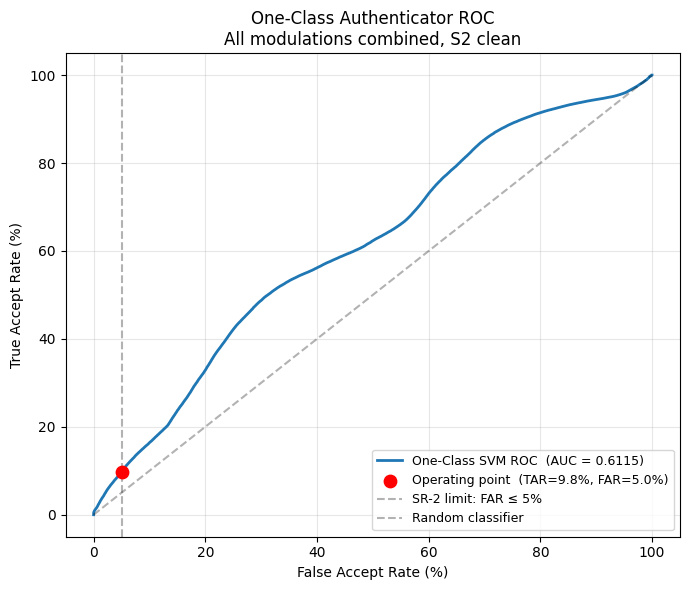

Saved: /content/drive/MyDrive/My Thesis (main)/Models/ExperimentC_v2/C2_roc_curve.png


In [9]:
# Collect scores across all modulations from S2 clean
all_scores_dev01, all_scores_dev02 = [], []

for mod in MODULATIONS:
    X, y = load_npy('S2', mod, 'clean')
    emb01 = scaler.transform(get_embeddings(X[y == 0]))
    emb02 = scaler.transform(get_embeddings(X[y == 1]))
    all_scores_dev01.extend(ocsvm.decision_function(emb01).tolist())
    all_scores_dev02.extend(ocsvm.decision_function(emb02).tolist())
    del X, y, emb01, emb02
    gc.collect()

scores_all = np.array(all_scores_dev01 + all_scores_dev02)
labels_all = np.array([1]*len(all_scores_dev01) + [0]*len(all_scores_dev02))

fpr, tpr, thresholds = roc_curve(labels_all, scores_all)
roc_auc = auc(fpr, tpr)

# Operating point at FAR = 5%
op_idx  = np.argmin(np.abs(fpr - TARGET_FAR))
op_tar  = tpr[op_idx] * 100
op_far  = fpr[op_idx] * 100

experiment_C_results['auc']    = float(roc_auc)
experiment_C_results['op_tar'] = float(op_tar)
experiment_C_results['op_far'] = float(op_far)

print(f'AUC          : {roc_auc:.4f}')
print(f'Operating pt : TAR={op_tar:.1f}%, FAR={op_far:.1f}%')

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr*100, tpr*100, lw=2, label=f'One-Class SVM ROC  (AUC = {roc_auc:.4f})')
ax.scatter([op_far], [op_tar], color='red', zorder=5, s=80,
           label=f'Operating point  (TAR={op_tar:.1f}%, FAR={op_far:.1f}%)')
ax.axvline(TARGET_FAR*100, color='gray', linestyle='--',
           alpha=0.6, label='SR-2 limit: FAR ≤ 5%')
ax.plot([0,100],[0,100], 'k--', alpha=0.3, label='Random classifier')
ax.set_xlabel('False Accept Rate (%)')
ax.set_ylabel('True Accept Rate (%)')
ax.set_title('One-Class Authenticator ROC\nAll modulations combined, S2 clean')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(MODEL_DIR, 'C2_roc_curve.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {roc_path}')

## Section 9 — TAR/FAR Heatmaps

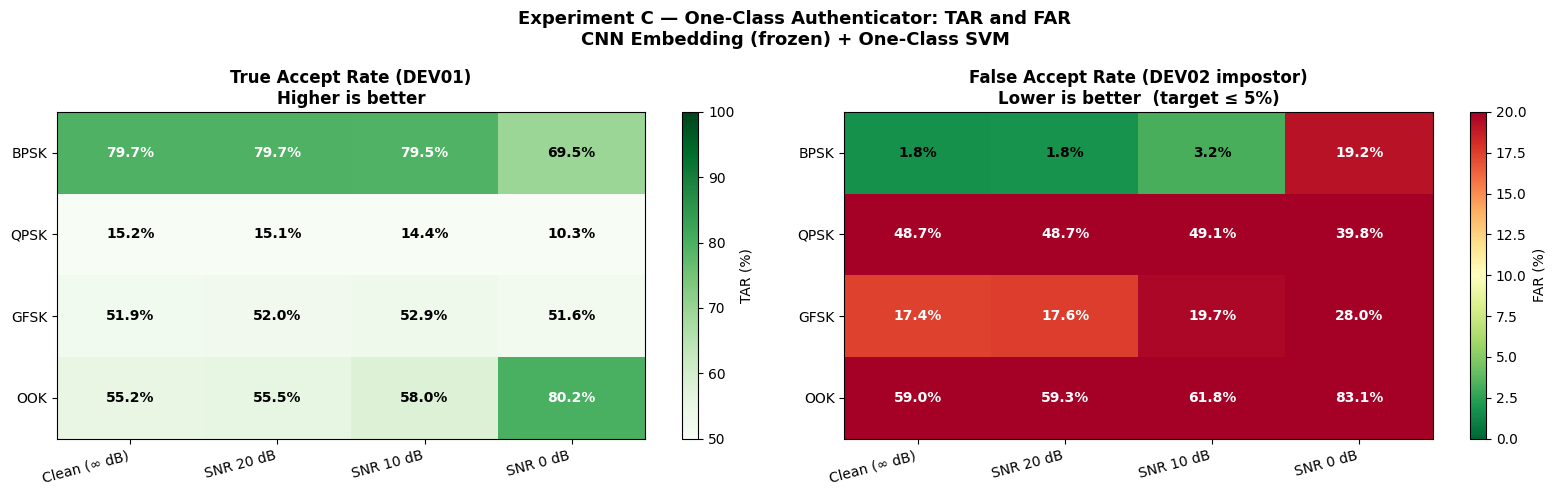

Saved: /content/drive/MyDrive/My Thesis (main)/Models/ExperimentC_v2/C2_tar_far_heatmap.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
snr_display = ['Clean (∞ dB)', 'SNR 20 dB', 'SNR 10 dB', 'SNR 0 dB']

tar_matrix = np.array([[tar_results[m][l] for l in snr_labels]
                        for m in MODULATIONS], dtype=float)
far_matrix = np.array([[far_results[m][l] for l in snr_labels]
                        for m in MODULATIONS], dtype=float)

# TAR heatmap
im1 = axes[0].imshow(tar_matrix, cmap='Greens', vmin=50, vmax=100, aspect='auto')
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(snr_display, rotation=15, ha='right')
axes[0].set_yticks(range(len(MODULATIONS)))
axes[0].set_yticklabels(MODULATIONS)
axes[0].set_title('True Accept Rate (DEV01)\nHigher is better', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='TAR (%)')
for i in range(len(MODULATIONS)):
    for j in range(4):
        v = tar_matrix[i, j]
        axes[0].text(j, i, f'{v:.1f}%', ha='center', va='center',
                     fontweight='bold', fontsize=10,
                     color='white' if v > 75 else 'black')

# FAR heatmap
im2 = axes[1].imshow(far_matrix, cmap='RdYlGn_r', vmin=0, vmax=20, aspect='auto')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(snr_display, rotation=15, ha='right')
axes[1].set_yticks(range(len(MODULATIONS)))
axes[1].set_yticklabels(MODULATIONS)
axes[1].set_title('False Accept Rate (DEV02 impostor)\nLower is better  (target ≤ 5%)',
                   fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='FAR (%)')
for i in range(len(MODULATIONS)):
    for j in range(4):
        v = far_matrix[i, j]
        axes[1].text(j, i, f'{v:.1f}%', ha='center', va='center',
                     fontweight='bold', fontsize=10,
                     color='white' if v > 10 else 'black')

fig.suptitle('Experiment C — One-Class Authenticator: TAR and FAR\n'
             'CNN Embedding (frozen) + One-Class SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
heatmap_path = os.path.join(MODEL_DIR, 'C2_tar_far_heatmap.png')
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {heatmap_path}')

## Section 10 — Embedding Space Visualisation (t-SNE)

Running t-SNE on 4000 embeddings...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


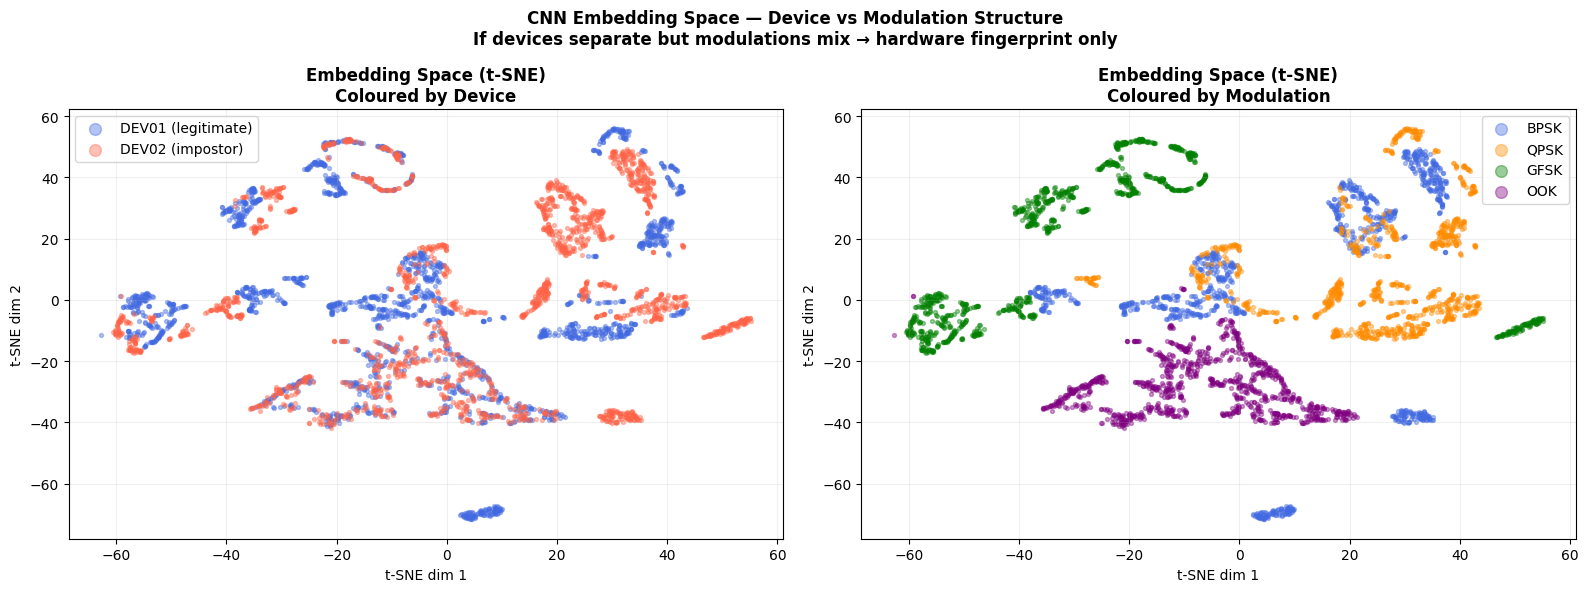

Saved: /content/drive/MyDrive/My Thesis (main)/Models/ExperimentC_v2/C2_tsne_embedding.png


In [11]:
from sklearn.manifold import TSNE

# Load a sample from each modulation — S2 clean, 500 windows per device
SAMPLE = 500
emb_vis, label_vis, mod_vis = [], [], []

for i, mod in enumerate(MODULATIONS):
    X, y = load_npy('S2', mod, 'clean')
    for dev_label in [0, 1]:
        X_dev = X[y == dev_label][:SAMPLE]
        emb   = get_embeddings(X_dev)
        emb_vis.append(emb)
        label_vis.extend([dev_label] * len(X_dev))
        mod_vis.extend([i] * len(X_dev))
    del X, y
    gc.collect()

emb_vis   = np.vstack(emb_vis)
label_vis = np.array(label_vis)
mod_vis   = np.array(mod_vis)

print(f'Running t-SNE on {len(emb_vis)} embeddings...')
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=50, n_iter=1000)
emb_2d = tsne.fit_transform(scaler.transform(emb_vis))

# Plot — colour by device, shape by modulation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors  = ['royalblue', 'tomato']
markers = ['o', 's', '^', 'D']
dev_names = ['DEV01 (legitimate)', 'DEV02 (impostor)']

# Left: colour by device
for dev in [0, 1]:
    mask = label_vis == dev
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=colors[dev], alpha=0.4, s=8, label=dev_names[dev])
axes[0].set_title('Embedding Space (t-SNE)\nColoured by Device', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_xlabel('t-SNE dim 1')
axes[0].set_ylabel('t-SNE dim 2')
axes[0].grid(True, alpha=0.2)

# Right: colour by modulation
mod_colors = ['royalblue', 'darkorange', 'green', 'purple']
for i, mod in enumerate(MODULATIONS):
    mask = mod_vis == i
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=mod_colors[i], alpha=0.4, s=8, label=mod)
axes[1].set_title('Embedding Space (t-SNE)\nColoured by Modulation', fontweight='bold')
axes[1].legend(markerscale=3)
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].grid(True, alpha=0.2)

fig.suptitle('CNN Embedding Space — Device vs Modulation Structure\n'
             'If devices separate but modulations mix → hardware fingerprint only',
             fontsize=12, fontweight='bold')
plt.tight_layout()
tsne_path = os.path.join(MODEL_DIR, 'C2_tsne_embedding.png')
plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {tsne_path}')

## Section 11 — Latency + Save Results

In [12]:
# Measure end-to-end inference latency: IQ → embedding → SVM decision
X_lat, _ = load_npy('S2', 'BPSK', 'clean')
single_iq = X_lat[:1]

# Warm-up
for _ in range(50):
    emb = embedding_model.predict(single_iq, verbose=0)
    _ = ocsvm.decision_function(scaler.transform(emb))

latencies = []
for _ in range(1000):
    t0  = time.perf_counter()
    emb = embedding_model.predict(single_iq, verbose=0)
    _   = ocsvm.decision_function(scaler.transform(emb))
    latencies.append((time.perf_counter() - t0) * 1000)

lat_median = float(np.median(latencies))
lat_p95    = float(np.percentile(latencies, 95))
pr1_pass   = lat_median < 10

print(f'End-to-end latency (CNN + SVM):')
print(f'  Median : {lat_median:.3f} ms')
print(f'  P95    : {lat_p95:.3f} ms')
print(f'  PR-1 (< 10ms): {"PASS" if pr1_pass else "FAIL"}')

experiment_C_results['latency_median_ms'] = lat_median
experiment_C_results['latency_p95_ms']    = lat_p95

del X_lat, single_iq
gc.collect()

# Save JSON
def make_serializable(obj):
    import numpy as np
    if isinstance(obj, (np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.int32, np.int64)):     return int(obj)
    if isinstance(obj, np.ndarray):               return obj.tolist()
    raise TypeError(f'Not serializable: {type(obj)}')

json_path = os.path.join(MODEL_DIR, 'experiment_C2_results.json')
with open(json_path, 'w') as f:
    json.dump(experiment_C_results, f, indent=2, default=make_serializable)
print(f'\nResults saved: {json_path}')

# Final summary
print('\n' + '='*60)
print('EXPERIMENT C — ONE-CLASS AUTHENTICATOR SUMMARY')
print('='*60)
print(f'AUC                  : {experiment_C_results["auc"]:.4f}')
print(f'Operating TAR @ FAR5%: {experiment_C_results["op_tar"]:.1f}%')
print(f'Latency median       : {lat_median:.3f} ms')
print()
print('TAR per modulation (Clean):')
for mod in MODULATIONS:
    print(f'  {mod:<6}: {tar_results[mod]["Clean"]:.2f}%')
print()
print('FAR per modulation (Clean):')
for mod in MODULATIONS:
    print(f'  {mod:<6}: {far_results[mod]["Clean"]:.2f}%')
print('='*60)
print('Experiment C complete.')

End-to-end latency (CNN + SVM):
  Median : 67.297 ms
  P95    : 127.028 ms
  PR-1 (< 10ms): FAIL

Results saved: /content/drive/MyDrive/My Thesis (main)/Models/ExperimentC_v2/experiment_C2_results.json

EXPERIMENT C — ONE-CLASS AUTHENTICATOR SUMMARY
AUC                  : 0.6115
Operating TAR @ FAR5%: 9.8%
Latency median       : 67.297 ms

TAR per modulation (Clean):
  BPSK  : 79.67%
  QPSK  : 15.18%
  GFSK  : 51.90%
  OOK   : 55.21%

FAR per modulation (Clean):
  BPSK  : 1.76%
  QPSK  : 48.71%
  GFSK  : 17.36%
  OOK   : 59.05%
Experiment C complete.
